# Projet de statistiques computationnelles  
Fait par Melinda Krouri et Charlie Oudinot. 
## Sommaire

1. Introduction
2. Etude fréquentiste du modèle
    1. Hypothèses
    2. Lois des variables aléatoires
    3. Vraisemblance
    4. Estimateur de $N$
    5. Biais et variance de l'estimateur
    6. Application sur le jeu de données
3. Modélisation bayésienne
    1. Application au jeu de données
    2. Moyenne à posteriori

## 1. Introduction
Notre objectif est d'estimer la taille $N$ d'une population, grâce aux modèles de capture-recapture, qui consistent à capturer un certain nombre d'individus lors d'une première campagne, puis de lancer une deuxième campagne de recapture, compter le nombre d'individus déjà marqués, et d'en déduire des informations utiles sur cette population.


Les modèles de capture-recapture sont donc très présents lors d'études concernant la faune, car ils permettent d'estimer des quantités difficilement calculables dans la vraie vie : il n'est pas facile de compter le nombre de lions présents en Afrique sans se tromper, et cela demanderait d'importants moyens.


On importe tout d'abord les modules nécessaires pour la suite :

In [103]:
import numpy as np
import pandas as pd
import scipy as sc
import matplotlib.pyplot as plt
import statsmodels.graphics.tsaplots as ts

On met nos observations dans un DataFrame, en rajoutant une colonne *captured_twice*, qui a pour valeur 1 si l'individu a été capturé lors des deux campagnes de capture.

In [104]:
data = pd.read_csv('./data/data_capture.csv')
data = data[['first_capture', 'second_capture']]
data['captured_twice'] = data['first_capture'] * data['second_capture']

On peut calculer à partir des observations, $N_1(\omega)$, $N_2(\omega)$ et $M(\omega)$ :

In [105]:
n1 = data['first_capture'].sum()
n2 = data['second_capture'].sum()
m = data['captured_twice'].sum()
n1, n2, m

(89, 112, 15)

## 2. Etude fréquentiste du modèle

### 2.1. Hypothèses

On note $N$ la taille de la population étudiée, qui est le paramètre que l'on souhaite estimer, $N_1$ le nombre d'individus capturés lors de la première campagne, $N_2$ le nombre d'individus capturés lors de la deuxième campagne, $M$ le nombre d'individus capturés lors de la deuxième campagne et qui étaient déjà marqués, et $p$ la probabilité de capture (inconnue).  

Dans le modèle étudié, on suppose que :

- le nombre d'individus ne varie pas entre les deux campagnes de capture : pas de décès, de naissances, ...
- la probabilité $p$ de capture est la même pour les deux captures, le marquage d'un individu n'influe pas sur sa probabilité de capture lors de la deuxième capture.

### 2.2. Lois des variables aléatoires

On a :

- $N_1 \sim Bin(N, p)$, car chacun des $N$ individus a une probabilité $p$ d'être capturé. Notons que $N_2$ suit la même loi, et ces deux variables aléatoires sont indépendantes.

- $M | N_1=n_1 \sim  Bin(n_1, p)$, car on veut savoir le nombre de capturés parmi ceux déjà marqués, d'où le $n_1$.

- $N_2 - M | (N_1=n_1, N_2=n_2) \sim Bin(N-n_1,p)$, car cette fois-ci on veut savoir le nombre de capturés parmi ceux qui n'étaient pas marqués, d'où le $N - n_1$.

### 2.3. Vraisemblance

On veut à présent calculer la vraisemblance $L$, fonction de $N$ et $p$, pour une observation $(m, n_1, n_2)$ :
\begin{align*}
    L(N, p) &=  P(M=m, N_1 = n_1, N_2=n_2) \\
    &= P(N_1=n_1, N_2=n_2) \cdot P(M=m | N_1 = n_1, N_2=n_2)\\
    &= P(N_1=n_1) \cdot P(N_2=n_2) \cdot P(M=m | N_1 = n_1, N_2=n_2) \text{\footnotesize, car $N_1 \perp N_2$}\\
    &= P(N_1=n_1) \cdot P(N_2=n_2) \cdot \dfrac{\left( \begin{array}{c} n_1 \\ m \end{array} \right) \left( \begin{array}{c} N - n_1 \\ n_2 - m\end{array} \right)}{\left( \begin{array}{c} N \\ n_2 \end{array} \right)} \text{\footnotesize, car $M\sim \mathcal{H}(N, n_2, n_1)$}\\
    &= \left( \begin{array}{c} N \\ n_1 \end{array} \right) \left( \begin{array}{c} N - n_1 \\ n_2 - m \end{array} \right) \left( \begin{array}{c} n_1 \\ m \end{array} \right) p^{n_1 + n_2}(1-p)^{2N-n_2 - n_1}\\
\end{align*}

Est-il facile de maximiser $L$ selon $N$ et $p$ ?  

Pour $p$, on pourrait passer à la log-vraisemblance, et facilement trouver le maximum de vraisemblance.  
Pour $N$ fixé :

\begin{align*}
    log(L(N, p)) = log( \left( \begin{array}{c} N \\ n_1 \end{array} \right) \left( \begin{array}{c} N - n_1\\ n_2 - m \end{array} \right) \left( \begin{array}{c} n_1 \\ m \end{array} \right) ) + (n_1 + n_2)log(p) + (2N-n_2 -n_1)log(1-p)\\
\end{align*}
On dérive en $p$ et on obtient :
\begin{align*}
    log(L(N, p)) = 0 \Leftrightarrow \dfrac{n_1 + n_2}{p} - \dfrac{2N-n_2 -n_1}{1-p} &= 0\\
    \Rightarrow\dfrac{n_1 + n_2}{p} &= \dfrac{2N-n_2 -n_1}{1-p}\\
    \Rightarrow (1-p)(n_1 + n_2) &= p(2N-n_2 -n_1)\\
    \Rightarrow p^* &= \dfrac{n_1 + n_2}{2N}
\end{align*}

Pour $N$, il n'est pas possible de dériver la fonction de vraisemblance car $N$ est entier, il n'est donc pas aussi simple de maximiser $L$.

### 2.4. Estimateur de N

Sachant $(N_1,N_2)$, la loi conditionnelle de M est une $\mathcal{H}(N, n_2, n_1)$, avec pour convention $\mathcal{H}(echantillon,tirages,positif)$.  
En effet, cela revient à tirer aléatoirement sans remise $n_2$ individus dans l'ensemble $N$ et compter le nombre d'individus déjà marqués ($n_1$) parmi ceux-ci.  

On a ainsi :
\begin{align*}
    P(M=m) &= \dfrac{\left( \begin{array}{c} n_1 \\ m \end{array} \right) \left( \begin{array}{c} N - n_1 \\ n_2 - m\end{array} \right)}{\left( \begin{array}{c} N \\ n_2 \end{array} \right)}\\
\end{align*}
On a comme précédemment, $P(M=m) = L(N,p) = L(N)$, car la vraisemblance ne dépend plus de $p$. Il nous faut donc maximiser cette vraisemblance.  

Inspirons nous de l'exemple des poissons dans l'étang, trouvé sur https://www.bibmath.net/dico/index.php?action=affiche&quoi=./m/maxivrais.html (1) qui est très semblable à notre situation.  

Soit $P_N =P(M=m)$, avec N individus. On a :

\begin{align*}
    \dfrac{P_N}{P_{N-1}} &= \dfrac{\left( \begin{array}{c} n_1 \\ m \end{array} \right) \left( \begin{array}{c} N - n_1 \\ n_2 - m\end{array} \right)}{\left( \begin{array}{c} N \\ n_2 \end{array} \right)} \times \dfrac{\left( \begin{array}{c} N - 1 \\ n_2 \end{array} \right)}{\left( \begin{array}{c} n_1 \\ m \end{array} \right) \left( \begin{array}{c} N - n_1 - 1\\ n_2 - m\end{array} \right)}\\
    &= \text{...}\\
    &= \dfrac{(N−n_1)(N−n_2)}{(N−n_1−n_2+m)N}\\
    &= \dfrac{N^2 - Nn_1 -Nn_2 + n_2n_1}{N^2 - Nn_1 -Nn_2 + Nm}\\
\end{align*}

Ainsi, afin de maximiser $P_N$, il faut augmenter $N$ tant que le rapport est supérieur à 1, et on garde le N pour lequel $\dfrac{P_N}{P_{N-1}} > 1$ et $\dfrac{P_{N+1}}{P_{N}} < 1$.  
Or, $\dfrac{P_N}{P_{N-1}} = 1 \Leftrightarrow n_2n_1 = Nm$, et on trouve enfin :

\begin{equation}
    \hat{N} = \dfrac{n_2n_1}{m}
\end{equation}

estimateur de $N$. Cet estimateur est notamment appelé estimateur de Lincoln-Petersen.  

Si $m=0$, on a que $\hat{N} = +\infty$.

### 2.5. Biais et variance de l'estimateur

On définit une fonction sim\_M, qui prend en paramètres $N$ et $p$, crée un échantillon selon le modèle étudié, et retourne le triplet $(n_1, n_2, m)$ .

In [106]:
def sim_M(N:int, p:float)-> tuple:
    """
        Fonction qui simule les variables aléatoires N1, N2, et M (nb d'individus capturés déjà marqués), sachant N et p
    """
    cond = True
    while cond:
        arr = np.random.choice([0,1], size=(N, 2), replace=True, p=[1-p, p])
        if np.sum(np.all(arr, axis=1)) != 0: # on fait tourner l'algo jusqu'à ce que m =/= 0
            cond = False
    return np.sum(arr[:,0]), np.sum(arr[:,1]), np.sum(np.all(arr, axis=1))

On fixe $N$ à 500, et $n_sim$ à 100, $n\_ sim$ étant le nombre de $\hat{N}$ que l'on souhaite simuler.

In [107]:
n_sim = 100 # nb de N_hat
N = 500

# on augmente la taille de l'échantillon en augmentant la valeur de p (plus d'individus vont être capturés)
for p in [.2, .3, .5, .7]:
    X = np.array([sim_M(N, p) for _ in range(n_sim)]) # n_sim vecteurs d'observations (N1, N2, M) 
    N_hats = [(x[0] * x[1])/x[2] for x in X]# vecteur d'estimations de N (est. de Lincoln-Petersen)
    print('p=', p, ' ; ', ' biais empirique : ', np.mean(N_hats) - N, '; variance empirique : ', np.var(N_hats))

p= 0.2  ;   biais empirique :  30.025178353360275 ; variance empirique :  11909.673082571424
p= 0.3  ;   biais empirique :  7.4034832426851835 ; variance empirique :  2893.1236257192945
p= 0.5  ;   biais empirique :  1.0064590216121587 ; variance empirique :  462.4107552840422
p= 0.7  ;   biais empirique :  0.7657778529053871 ; variance empirique :  70.44741450075401


On remarque que :

- on a l'impression que l'estimateur admet un léger biais lorsque la taille de l'échantillon est petit ($p$ est petit, et donc peu d'individus sont recapturés)
- pour un $p$ assez grand, et donc une valeur de $m$ plus grande, l'estimateur est sans biais
- la variance diminue lorque $p$ augmente
- $n\_ sim$ ne change pas le biais ni la variance de l'estimateur à partir du moment où il est un minimum grand (pour $n\_sim = 10$, ne marche pas très bien)  

Proposons une approche bootstrap pour construire un intervalle de confiance pour $N$.

Soit une population de taille $N$. On simule un échantillon selon le modèle de capture-recapture à deux campagnes, avec une probabilité $p$ d'être capturé pour chaque individu. A partir de cet échantillon de taille $N$, on ré-échantillone selon la méthode bootstrap, c'est-à-dire en tirant aléatoirement $N$ individus, avec remise. On obtient ainsi $B$ (fixé auparavant) échantillons bootstrap.

Enfin, on calcule $\hat{N}^*$ pour chaque échantillon bootstrap, puis on peut obtenir un intervalle de confiance bootstrap de niveau $1-\alpha$, de la forme :
\begin{equation*}
    \hat{IC}_{boot} (1 − \alpha)^∗ = \left[2\hat{N} − \hat{N}_{(\lceil B(1-\frac{\alpha}{2})\rceil )}^∗ ; 2\hat{N} − \hat{N}_{(\lceil B\frac{\alpha}{2}\rceil )}^∗ \right]
\end{equation*}
avec $\hat{N}$ l'estimation de $N$ avec l'échantillon de départ.  

Voici la démarche à suivre :

In [108]:
B = 1000# nb d'échantillons bootstrap
N = 500
p = .4
alpha = 0.1 # IC à 90%

# on simule un échantillon
cond = True
while cond:
    X = np.random.choice([0,1], size=(N, 2), replace=True, p=[1-p, p])
    if np.sum(np.all(X, axis=1)) != 0: # on fait tourner l'algo jusqu'à ce que m =/= 0
        cond = False
N_hat = (np.sum(X[:,0]) * np.sum(X[:,1])) / np.sum(np.all(X, axis=1)) 

# partie bootstrap
Xs_b = []
for b in range(B):    
    ind_b = np.random.randint(0, N, size=N)
    Xs_b.append(np.array([X[i] for i in ind_b]))

# calcul de l'estimateur bootstrap pour chaque éch bootstrap
N_hats_b = [(np.sum(x[:,0]) * np.sum(x[:,1])) / np.sum(np.all(x, axis=1)) for x in Xs_b]
N_hats_b.sort() # on trie les valeurs par ordre croissant

# construction de l'intervalle de confiance bootstrap
IC = (2*N_hat - N_hats_b[int(np.ceil(B*(1-alpha/2)))], 2*N_hat - N_hats_b[int(np.ceil(B*(alpha/2)))])

Pour calculer le taux de couverture de l'intervalle de confiance construit, on va répéter  cet algorithme $T$ fois, puis compter combien de fois la vraie valeur ($N$) est comprise dans l'intervalle de confiance.

On a choisi un intervalle de confiance à 10%, c'est-à-dire que le taux de couverture devrait se situer aux alentours des 90%. On fixe $T = 1000$.

In [109]:
rate = 0
T = 50
for _ in range(T):
    # on simule un échantillon
    cond = True
    while cond:
        X = np.random.choice([0,1], size=(N, 2), replace=True, p=[1-p, p])
        if np.sum(np.all(X, axis=1)) != 0: # on fait tourner l'algo jusqu'à ce que m =/= 0
            cond = False
    N_hat = (np.sum(X[:,0]) * np.sum(X[:,1])) / np.sum(np.all(X, axis=1)) 

    # partie bootstrap
    Xs_b = []
    for b in range(B):    
        ind_b = np.random.randint(0, N, size=N)
        Xs_b.append(np.array([X[i] for i in ind_b]))

    # calcul de l'estimateur bootstrap pour chaque éch bootstrap
    N_hats_b = [(np.sum(x[:,0]) * np.sum(x[:,1])) / np.sum(np.all(x, axis=1)) for x in Xs_b]
    N_hats_b.sort() # on trie les valeurs par ordre croissant

    # construction de l'intervalle de confiance bootstrap
    IC = (2*N_hat - N_hats_b[int(np.ceil(B*(1-alpha/2)))], 2*N_hat - N_hats_b[int(np.ceil(B*(alpha/2)))])

    # màj du taux de couverture
    if 500 > IC[0] and 500 < IC[1]:
        rate += 1/T

print(rate)

0.9400000000000006


On trouve donc que le taux de couverture est proche de 90%, l'intervalle de confiance proposé est ainsi assez bon.

### 2.6. Application sur le jeu de données

On va maintenant appliquer la métohde bootstrap à notre jeu de données *data_capture*.

In [110]:
alpha = .1

X = np.array(data[['first_capture', 'second_capture']])
N_hat = (np.sum(X[:,0]) * np.sum(X[:,1])) / np.sum(np.all(X, axis=1)) 
N_hat

# partie bootstrap
Xs_b = []
for b in range(B):    
    ind_b = np.random.randint(0, X.shape[0], size=X.shape[0])
    Xs_b.append(np.array([X[i] for i in ind_b]))

# calcul de l'estimateur bootstrap pour chaque éch bootstrap
N_hats_b = [(np.sum(x[:,0]) * np.sum(x[:,1])) / np.sum(np.all(x, axis=1)) for x in Xs_b]
N_hats_b.sort() # on trie les valeurs par ordre croissant

# construction de l'intervalle de confiance bootstrap
IC = (2*N_hat - N_hats_b[int(np.ceil(B*(1-alpha/2)))], 2*N_hat - N_hats_b[int(np.ceil(B*(alpha/2)))])

IC

(293.0666666666666, 839.6575757575756)

On trouve ainsi un intervalle de confiance au niveau 90% pour $N$, c'est-à-dire que $N$ a une probabilité égale à 90% de se trouver dans cet intervalle.  
L'intervalle est assez large, on pourrait baisser le niveau, au risque que N ne se trouve pas dans l'intervalle.

## 3. Modélisation bayésienne

Il faut à présent faire une supposition sur la loi du vecteur $(N, p)$, trouver la vraisemblance selon $(N, p)$, afin d'en déduire une loi a priori pour $(N, p)$.  

On sait que $p$ se situera entre $0$ et $1$ car c'est une probabilité, mais on ne peut pas supposer plus car nous n'avons pas d'informations sur les campagnes de capture.  

Quant à $N$, on sait qu'il sera supérieur à $\max (n_1, n_2)$, mais nous n'avons aucune idée sur la borne supérieure.

On a donc :

- $p \in \left[0,1\right]$

- $N \geq \max (n_1, n_2)$

N'ayant pas plus d'informations, on va supposer :

- $p \sim \mathcal{U}(\left[0,1\right])$ la loi uniforme continue sur $\left[0,1\right]$

- $N \sim \mathcal{U}(\left[max(n_1, n_2),1000\right])$ la loi uniforme discrète sur $\left[max(n_1, n_2),1000\right]$. Le choix du $1000$ est assez arbitraire, on a préféré prendre large.

La vraisemblance $L(N, p)$ a précédemment été calculé et vaut :

\begin{equation*}
    L(N, p) = \left( \begin{array}{c} N \\ n_1 \end{array} \right) \left( \begin{array}{c} N - n_1 \\ n_2 - m \end{array} \right) \left( \begin{array}{c} n_1 \\ m \end{array} \right) p^{n_1 + n_2}(1-p)^{2N-n_2 - n_1}
\end{equation*}

In [111]:
def L(n1, n2, m, N, p):
    return sc.special.binom(N, n1) * sc.special.binom(N - n1, n2 - m) * sc.special.binom(n1, m) * p**(n1 + n2) * (1 - p)**(2*N - n1 - n2)

def prior_N(N, n1, n2):
    if N < max(n1, n2):
        return 0
    return 1/(1000 - max(n1, n2))

On a que la loi a posteriori est égale à une constante près à :

\begin{equation*}
    P(N,p|n_1, n_2, m) \propto L(N,p) \cdot \pi_N \cdot \pi_p
\end{equation*}
On peut la définir :

In [112]:
def posterior(n1, n2, m, N, p):
    return L(n1, n2, m, N, p) * prior_N(N, n1, n2)

### 3.1. Application au jeu de données

Si l'on fixe $p$, alors on peut tracer la densité de la loi a posteriori de $N$ :

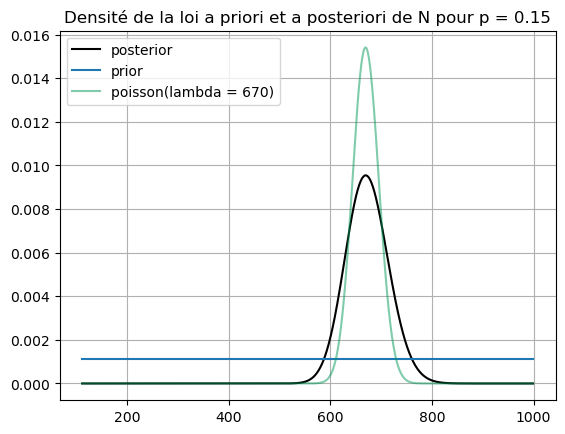

In [113]:
n1, n2, m, p = 89, 112, 15, 0.15
N_vals = np.arange(max(n1, n2), 1000)

posterior_dens = np.array([])
for N in N_vals:
    posterior_dens = np.append(posterior_dens, posterior(n1, n2, m, N, p))
posterior_dens = posterior_dens / np.sum(posterior_dens) # on normalise pour obtenir une densité
plt.plot(N_vals, posterior_dens, label='posterior', c=(0,0,0))
plt.plot(N_vals, [prior_N(y, n1, n2) for y in N_vals], label='prior')
plt.plot(N_vals, sc.stats.poisson.pmf(N_vals, 670), label='poisson(lambda = 670)', c=(0,.6,0.35, 0.5))

plt.grid()
plt.legend()
plt.title('Densité de la loi a priori et a posteriori de N pour p = ' + str(p))
plt.show()

On remarque la loi de $N$ est fortement modifiée, elle passe d'une loi loi uniforme sur $\left[max(n_1, n_2),1000\right]$, à ce qui ressemble à une loi de poisson de paramètre $\lambda = \hat{N}$.

On peut également tracer un graphe de la loi jointe a posteriori $p(\theta|x)$.

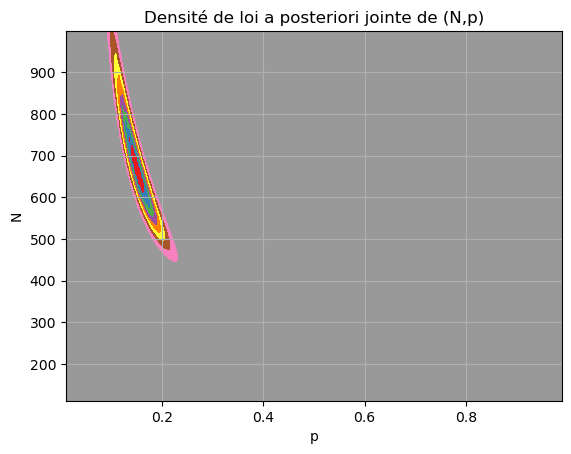

In [114]:
n1,n2,m = 89,112,15

N_vals = np.arange(max(n1, n2), 1000)
p_vals = np.linspace(0.01, 0.99, 150)
posterior_grid = np.zeros((len(N_vals), len(p_vals)))

for i, N in enumerate(N_vals):
    for j, p in enumerate(p_vals):
        posterior_grid[i, j] = posterior(n1, n2, m, N, p)

plt.contourf(p_vals, N_vals, posterior_grid, levels=30, cmap="Set1_r")
plt.xlabel("p")
plt.ylabel("N")
plt.grid()
plt.title("Densité de loi a posteriori jointe de (N,p)")
plt.show()

On voit que la densité jointe admet des valeurs plus élevées lorsque $N$ se situe entre $600$ et $700$, et p entre $0.1$ et $0.15$.

### 3.2. Moyenne à posteriori

La moyenne à posteriori est définie comme l'espérance de la loi a posteriori.

Par la loi des grands des grands nombres, il nous faut générer un grand nombre de $N$ selon la loi a posteriori, puis calculer la moyenne empirique de ces valeurs.

On connaît la loi a posteriori à une constante près, on peut donc utiliser l'algorithme de Metropolis-Hastings pour simuler selon cette loi.

In [115]:
n1, n2, m = 89, 112, 15 # on fixe de nouveau les données
n_iterations = 10000
step_N, step_p = 100, .05 # valeur de la marche aléatoire pour N et p respectivement
count = 0 # calcul du taux d'acceptation

# on initialise N_0 et p_0
Ns = [650, ] 
ps = [0.2, ]

for i in range(n_iterations):
    N = max(n1, n2, Ns[i] + np.random.randint(-step_N, step_N+1))
    p = max(0, ps[i] + np.random.uniform(-step_p, step_p))
    alpha = min(1, posterior(n1, n2, m, N, p) / posterior(n1, n2, m, Ns[i], ps[i])) # pas de rapport de densités q car marche aléatoire centrée autour de la valeur précédente
    
    if np.random.uniform() < alpha:
        Ns.append(N)
        ps.append(p)
        count += 1
    else:
        Ns.append(Ns[i])
        ps.append(ps[i])

Notons qu'il faut parfois relancer plusieurs fois l'algorithme pour qu'il ne renvoie pas d'erreur. J'ai dû oublier une indicatrice dans l'expression d'une densité.

On trace ensuite l'évolution des chaînes de Markov construites :

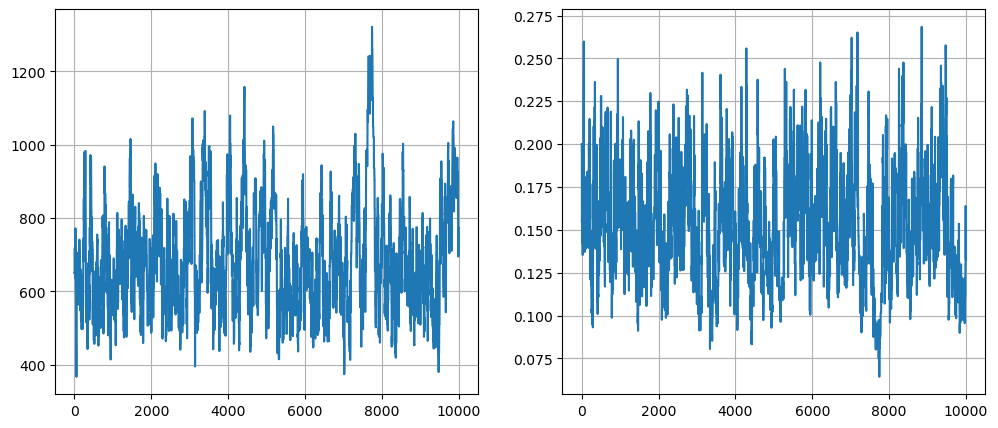

In [116]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12,5))

ax[0].plot(np.arange(len(Ns)), Ns)
ax[1].plot(np.arange(len(ps)), ps)

ax[0].grid()
ax[1].grid()
plt.show()

On a modifié le pas et l'initialisation jusqu'à obtenir une chaîne qui ne reste pas constante, et qui ne reste pas trop longtemps dans la même zone de l'espace.

Il faut également que la corrélation entre les valeurs des chaînes diminue rapidement, on peut vérifier cela avec le graphe d'autocorrélation.

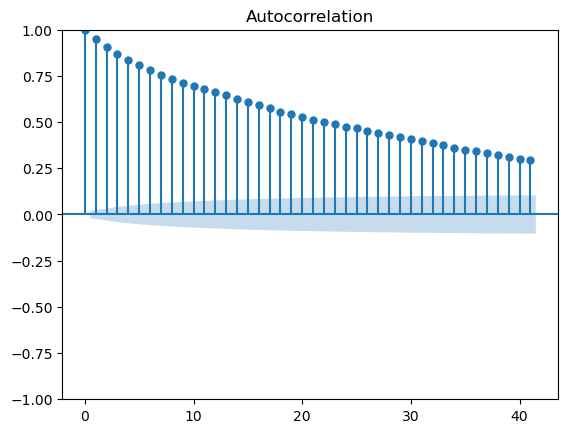

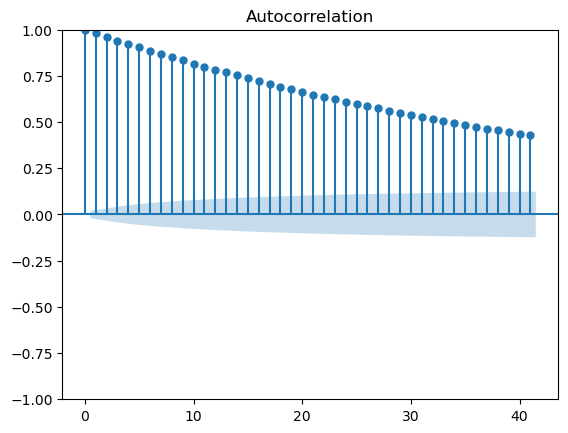

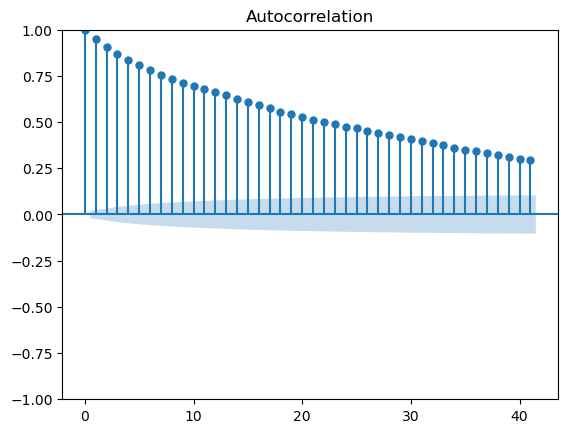

In [117]:
ts.plot_acf(np.array(Ns))
ts.plot_acf(np.array(ps))

Ce n'est pas vraiment le cas ici, mais nous n'avons pas réussi à modifier l'algorithme de telle façon à faire baisser l'autocorrélation.

Pour calculer la moyenne a posteriori de $N$ et $p$, il suffit de calculer la moyenne empirique des chaînes de Markov :

In [118]:
print('moyenne a priori de N = ', np.mean(Ns))
print('moyenne a priori de p = ', np.mean(ps))

moyenne a priori de N =  690.8783121687832
moyenne a priori de p =  0.15258108117119554


On veut maintenant construire un intervalle de crédibilité à 95%, pour $N$ et $p$.